<b>Лаборатона робота №1</b><br>
<br>
<b>Виконали:</b><br>
Сачек Вледислава КА-31<br>
Плахтій Злата КА-32<br>
Богданова Олександра КА-32<br>

<b>Хід роботи:</b><br>
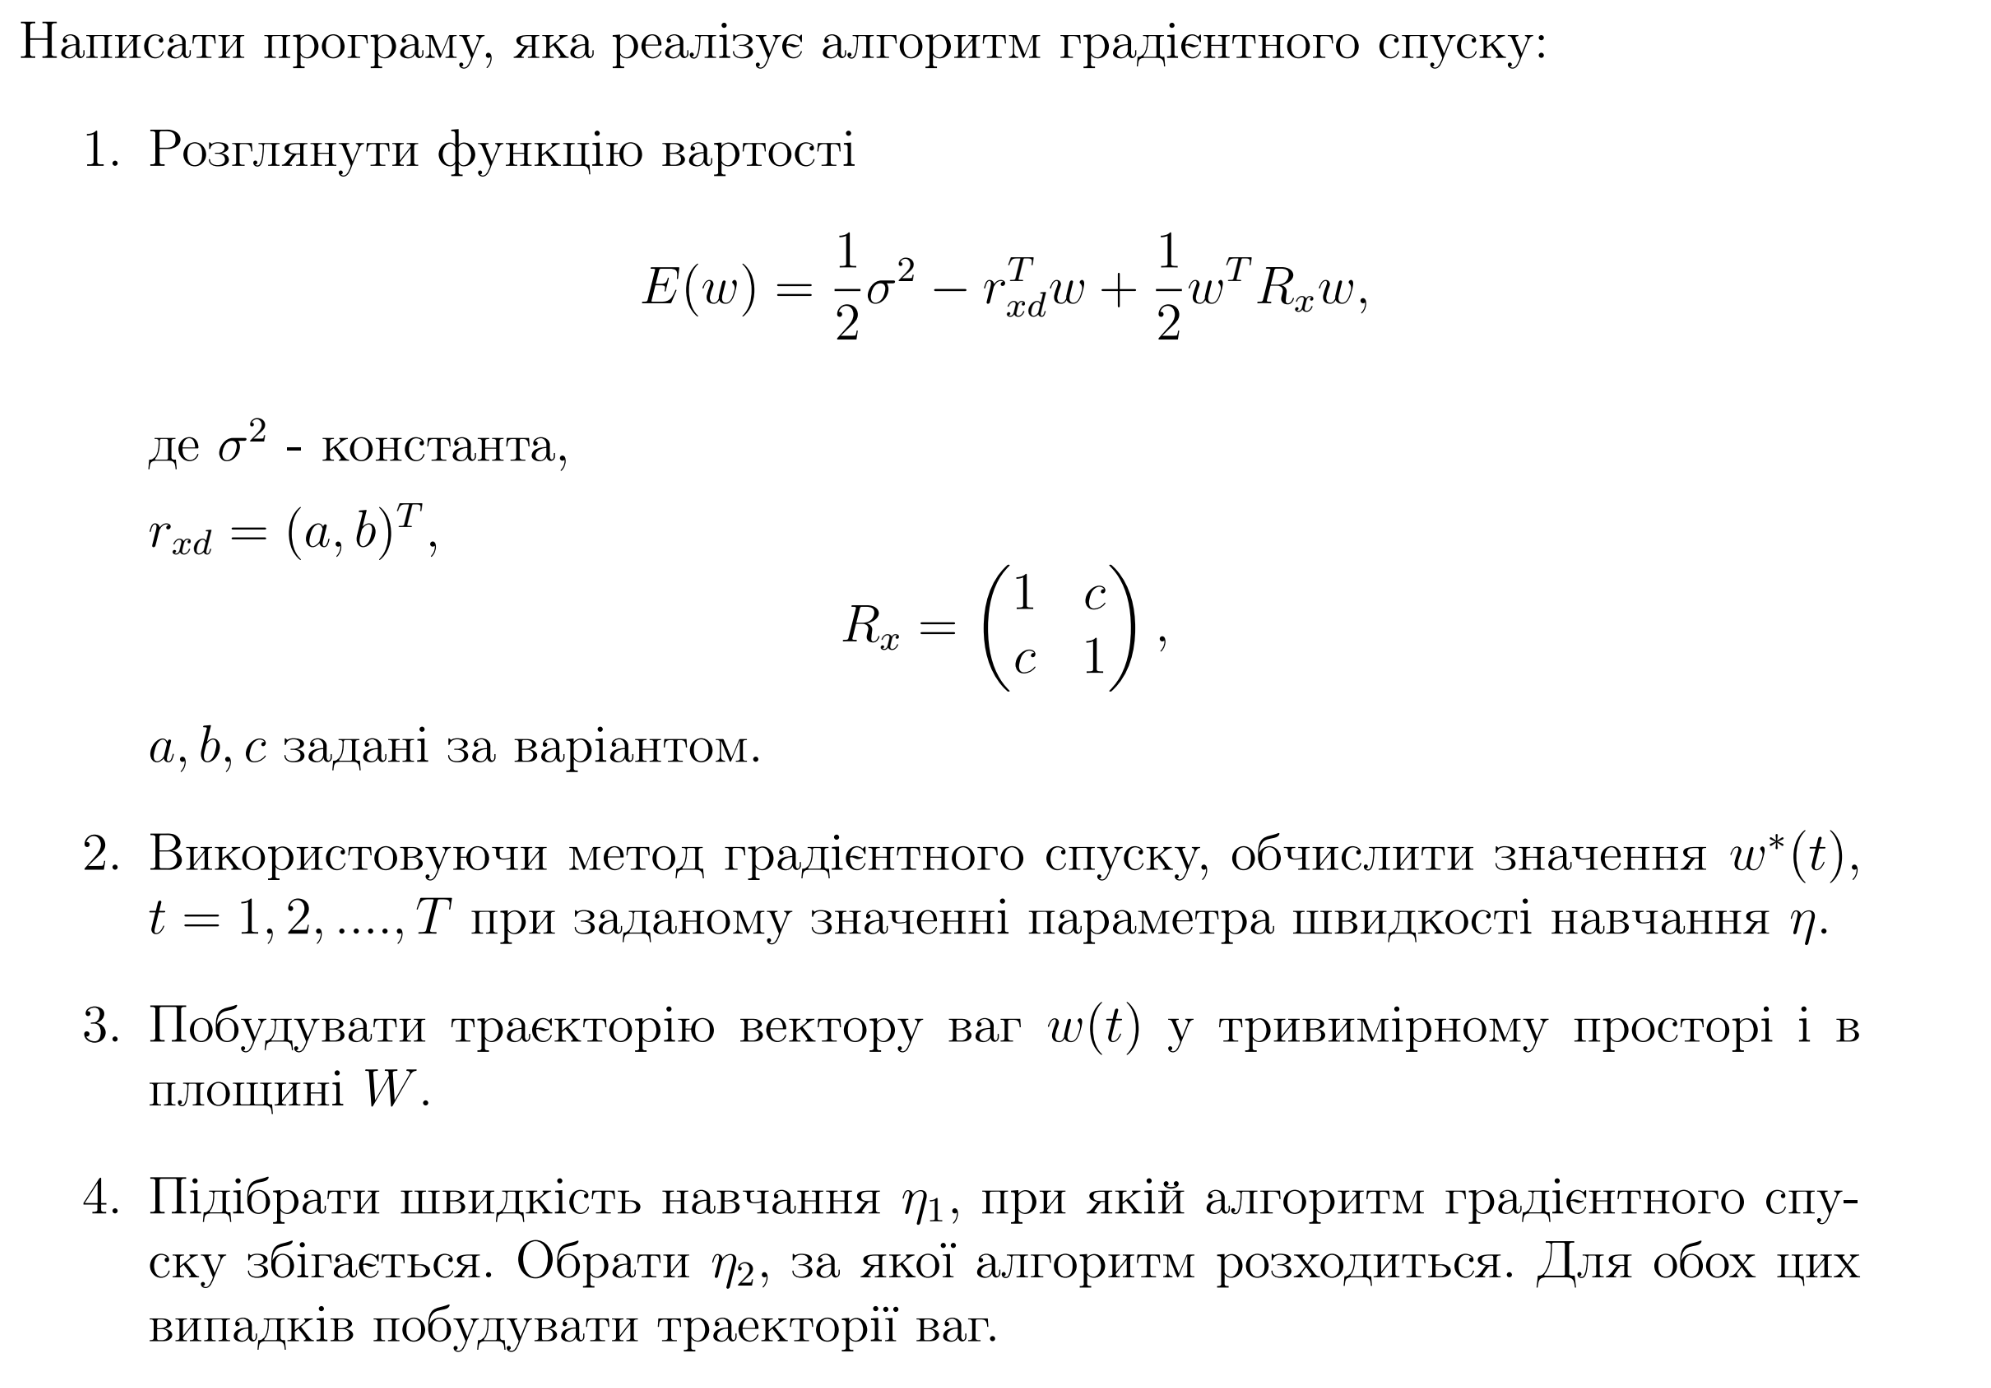
<b>Варіант завдання:</b><br>
2. a = 0.5, b = 0.6, c = 0.7, η = 1.6


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Параметри варіанту 2
a, b, c = 0.5, 0.6, 0.7
sigma2 = 1.0
r = np.array([a, b])
R = np.array([[1, c], [c, 1]])

# Аналітичний оптимум
w_star = np.linalg.solve(R, r)

# Умова збіжності
lam_max = np.linalg.eigvalsh(R).max()
eta_max = 2 / lam_max
eta1 = 0.8  
eta2 = 1.6  

print(f"w* = {w_star}")
print(f"η_max = {eta_max:.4f}  →  η1={eta1}  η2={eta2} ")

def E(w):
    return 0.5*sigma2 - r @ w + 0.5 * w @ R @ w

def grad(w):
    return R @ w - r

def gradient_descent(eta, w0, T=60):
    w = w0.copy()
    hist = [w.copy()]
    for _ in range(T):
        w = w - eta * grad(w)
        hist.append(w.copy())
        if np.linalg.norm(w) > 1e6:
            break
    return np.array(hist)

w0 = np.array([2.0, -1.5])
h1 = gradient_descent(eta1, w0)
h2 = gradient_descent(eta2, w0, T=25)



w* = [0.15686275 0.49019608]
η_max = 1.1765  →  η1=0.8  η2=1.6 


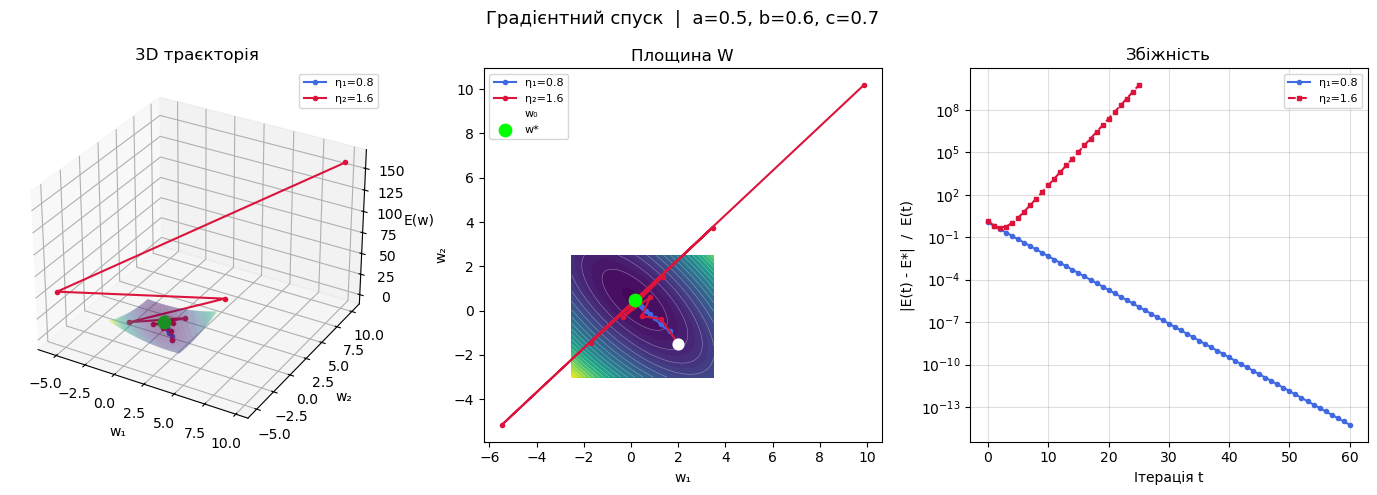

In [4]:
# Графіки 
W1, W2 = np.meshgrid(np.linspace(-2.5, 3.5, 100), np.linspace(-3, 2.5, 100))
EE = np.vectorize(lambda w1, w2: E(np.array([w1, w2])))(W1, W2)

fig = plt.figure(figsize=(14, 5))
fig.suptitle(f"Градієнтний спуск  |  a={a}, b={b}, c={c}", fontsize=13)

# 3D
ax3 = fig.add_subplot(131, projection='3d')
ax3.plot_surface(W1, W2, EE, cmap='viridis', alpha=0.5, linewidth=0)
for h, col, lbl in [(h1,'royalblue',f'η₁={eta1}'), (h2,'crimson',f'η₂={eta2}')]:
    mask = np.abs(h).max(axis=1) < 15
    hw = h[mask]
    ax3.plot(hw[:,0], hw[:,1], [E(w) for w in hw], 'o-', color=col, ms=3, lw=1.5, label=lbl)
ax3.scatter(*w_star, E(w_star), color='lime', s=80, zorder=5)
ax3.set_xlabel('w₁'); ax3.set_ylabel('w₂'); ax3.set_zlabel('E(w)')
ax3.set_title('3D траєкторія'); ax3.legend(fontsize=8)

# Площина W
ax2 = fig.add_subplot(132)
ax2.contourf(W1, W2, EE, levels=40, cmap='viridis')
ax2.contour(W1, W2, EE, levels=20, colors='white', linewidths=0.4, alpha=0.4)
for h, col, lbl in [(h1,'royalblue',f'η₁={eta1}'), (h2,'crimson',f'η₂={eta2}')]:
    mask = np.abs(h).max(axis=1) < 15
    hw = h[mask]
    ax2.plot(hw[:,0], hw[:,1], 'o-', color=col, ms=3, lw=1.5, label=lbl)
ax2.scatter(*w0, color='white', s=60, zorder=5, label='w₀')
ax2.scatter(*w_star, color='lime', s=80, zorder=5, label='w*')
ax2.set_xlabel('w₁'); ax2.set_ylabel('w₂')
ax2.set_title('Площина W'); ax2.legend(fontsize=8)

# E(t)
ax_e = fig.add_subplot(133)
E1 = [E(w) for w in h1]
ax_e.semilogy(np.abs(E1 - E(w_star)), 'o-', color='royalblue', ms=3, lw=1.5, label=f'η₁={eta1}')
mask2 = np.abs(h2).max(axis=1) < 1e6
E2 = [E(w) for w in h2[mask2]]
ax_e.plot(range(len(E2)), E2, 's--', color='crimson', ms=3, lw=1.5, label=f'η₂={eta2}')
ax_e.set_xlabel('Ітерація t'); ax_e.set_ylabel('|E(t) - E*|  /  E(t)')
ax_e.set_title('Збіжність'); ax_e.legend(fontsize=8); ax_e.grid(True, which='both', alpha=0.4)

plt.tight_layout()
plt.show()